### 1. Load all records from restaurants table into a DataFrame

In [1]:
import sqlite3
import pandas as pd

# Connect to local SQLite database
conn = sqlite3.connect("my_database.db")

# Load all records from restaurants table
df_restaurants = pd.read_sql("SELECT * FROM restaurants", conn)

# Display first 5 rows
df_restaurants

,id,name,cuisine,rating
0,1,Spice Hub,Indian,4.5
1,2,Pasta Palace,Italian,4.2
2,3,Sushi World,Japanese,4.8
3,4,Burger Town,American,3.9
4,5,Taco Fiesta,Mexican,4.1


### 2. Use %sql magic to query movies with rating > 8

In [2]:
# Load ipython-sql extension
%load_ext sql

# Connect to SQLite database
%sql sqlite:///my_database.db

# Run SQL query
%sql SELECT * FROM movies WHERE rating > 8;

 * sqlite:///my_database.db
Done.


id,title,rating
1,Inception,8.8
2,The Dark Knight,9.0
3,Interstellar,8.6
5,Parasite,8.6


### 3. Analyze Zomato-style orders: top 3 most ordered food items

In [3]:
# Load last 5 orders --- since small size of the dataset
df_orders = pd.read_sql("SELECT * FROM orders ORDER BY order_id DESC LIMIT 100", conn)

# Find top 3 most ordered food items
top_items = df_orders['food_item'].value_counts()

top_items.head(3)


food_item
Pizza     5
Burger    2
Taco      1
Name: count, dtype: int64

### 4. IPL matches bar chart: matches played per team

C:\Users\allex\AppData\Local\Temp\ipykernel_22392\1685730060.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_counts.index, y=team_counts.values, palette="viridis")


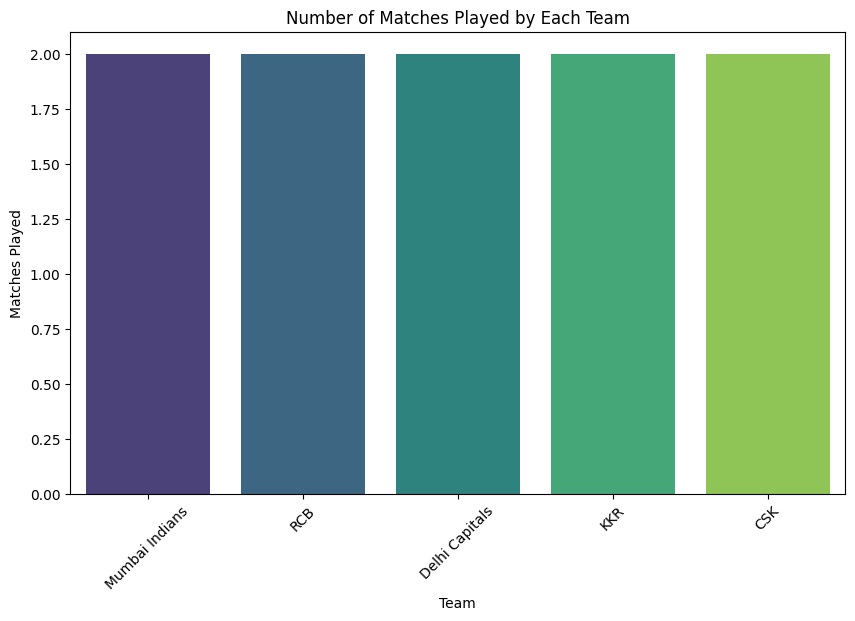

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load matches table
df_matches = pd.read_sql("SELECT * FROM matches", conn)

# Count matches per team (team1 and team2 both count)
team_counts = pd.concat([df_matches['team1'], df_matches['team2']]).value_counts()

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=team_counts.index, y=team_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Number of Matches Played by Each Team")
plt.xlabel("Team")
plt.ylabel("Matches Played")
plt.show()


### 5. Jupyter Notebook cell: users with > 3 orders

In [5]:
# SQL query to fetch users with more than 3 orders
query = """
SELECT user_id, COUNT(order_id) AS total_orders
FROM orders
GROUP BY user_id
HAVING COUNT(order_id) > 3;
"""

df_users = pd.read_sql(query, conn)

df_users


,user_id,total_orders
0,1,4
